# K-means algorithm

In [527]:
import pandas as pd

In [528]:
# import cleaned data

df_fv = pd.read_parquet('./data_source/data_query_for_fac_ventas.parquet')

In [529]:
df_fv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7701 entries, 0 to 7700
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   NUMERO_DE_IDENTIFICACION  7701 non-null   int64         
 1   PRIMER_APELLIDO           7701 non-null   object        
 2   SEGUNDO_APELLIDO          7701 non-null   object        
 3   PRIMER_NOMBRE             7701 non-null   object        
 4   SEGUNDO_NOMBRE            7701 non-null   object        
 5   CURSO                     7701 non-null   category      
 6   CELULAR                   7701 non-null   int64         
 7   CORREO                    5002 non-null   object        
 8   PRECIO_NETO               7701 non-null   float64       
 9   FECHA_DE_PAGO             7701 non-null   datetime64[ns]
 10  RENOVACION                7701 non-null   category      
 11  FECHA_DE_VENTA            7701 non-null   datetime64[ns]
 12  PROFESION           

## 1. Preparing the DataFrame for K-Means

Before running the K-Means clustering algorithm, we need to adapt the dataset to include only the most relevant variables. We will aggregate the data at the customer level to calculate their total number of purchases, total spend (or revenue generated), age, and gender.

-----

In [530]:
df_km_fv = df_fv[['NUMERO_DE_IDENTIFICACION', 'PRECIO_NETO', 'GENERO', 'EDAD']].copy()
df_km_fv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7701 entries, 0 to 7700
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   NUMERO_DE_IDENTIFICACION  7701 non-null   int64   
 1   PRECIO_NETO               7701 non-null   float64 
 2   GENERO                    7701 non-null   category
 3   EDAD                      5223 non-null   float64 
dtypes: category(1), float64(2), int64(1)
memory usage: 188.3 KB


### a. Find and remove invalid fields for k-means analysis
-----

##### Analysis for EDAD
EDAD column has 5,223 not null values, so data set will require to remove null values to continue with the analysis due invalid age data represent 0.8 %

In [531]:
# Number of null records
df_km_fv['EDAD'].isnull().sum()

np.int64(2478)

In [532]:
# Number of invalid ages
df_km_fv.loc[(df_km_fv['EDAD'] <= 12) | (df_km_fv['EDAD'] > 120)]['EDAD'].count()

np.int64(46)

In [533]:
# percentage % of invalid ages
(df_km_fv.loc[df_km_fv['EDAD'] <= 12]['EDAD'].count())*100 / df_km_fv['NUMERO_DE_IDENTIFICACION'].count()

np.float64(0.5973250227243215)

In [534]:
# percentage % of null ages
(df_km_fv.loc[df_km_fv['EDAD'].isnull()]['NUMERO_DE_IDENTIFICACION'].count())*100 / df_km_fv['NUMERO_DE_IDENTIFICACION'].count()

np.float64(32.17763926762758)

In [535]:
"""
We will remove those rows with null values and under 12 years old age, this because those data 
alrready passed for a data review and cleaning, where we try to complete missing information.
"""

# Remove null values
df_km_fv = df_km_fv.dropna(subset=['EDAD'])

# Remove age values under 12 years old
df_km_fv = df_km_fv.loc[(df_km_fv['EDAD'] > 12) & (df_km_fv['EDAD'] <= 120)]

df_km_fv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5177 entries, 0 to 7692
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   NUMERO_DE_IDENTIFICACION  5177 non-null   int64   
 1   PRECIO_NETO               5177 non-null   float64 
 2   GENERO                    5177 non-null   category
 3   EDAD                      5177 non-null   float64 
dtypes: category(1), float64(2), int64(1)
memory usage: 167.0 KB


##### Analysis for PRECIO_NETO

How many fields are creo on PRECIO_NETO column and what is its percentage, will those values to interfere in clusterig analysis?
We have desided remove cero value fields on columns PRECIO_NETO, due it represent a gift course for the customer

In [536]:
# Number of cero values
df_km_fv.loc[df_km_fv['PRECIO_NETO'] == 0]['PRECIO_NETO'].count()

np.int64(393)

In [537]:
# percentage % of cero values
(df_km_fv.loc[df_km_fv['PRECIO_NETO'] == 0]['PRECIO_NETO'].count())*100 / df_km_fv['PRECIO_NETO'].count()

np.float64(7.591269074753718)

In [538]:
# Leaving only values greater than cero

df_km_fv = df_km_fv.loc[df_km_fv['PRECIO_NETO'] != 0]
df_km_fv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4784 entries, 0 to 7692
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   NUMERO_DE_IDENTIFICACION  4784 non-null   int64   
 1   PRECIO_NETO               4784 non-null   float64 
 2   GENERO                    4784 non-null   category
 3   EDAD                      4784 non-null   float64 
dtypes: category(1), float64(2), int64(1)
memory usage: 154.3 KB


##### Handling Missing Values in Gender

There are 555 records with an UNKNOWN value in the GENERO column. We will remove these records because an unknown gender does not provide meaningful information for clustering. Keeping these blank or generic labels would introduce noise and reduce the accuracy of our customer segmentation.


In [539]:
df_km_fv.loc[df_km_fv['GENERO'] == 'UNKNOWN']['GENERO'].count()

np.int64(555)

In [540]:
(df_km_fv.loc[df_km_fv['GENERO'] == 'UNKNOWN']['GENERO'].count())*100 / df_km_fv['NUMERO_DE_IDENTIFICACION'].count()

np.float64(11.601170568561873)

In [541]:
# Remove customers without age field
df_km_fv = df_km_fv.loc[df_km_fv['GENERO'] != 'UNKNOWN']
df_km_fv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4229 entries, 0 to 7692
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   NUMERO_DE_IDENTIFICACION  4229 non-null   int64   
 1   PRECIO_NETO               4229 non-null   float64 
 2   GENERO                    4229 non-null   category
 3   EDAD                      4229 non-null   float64 
dtypes: category(1), float64(2), int64(1)
memory usage: 136.4 KB


### b. Calculate and prepare DataFrame fro K-means algorithm

-----

In [542]:
df_km = df_km_fv.groupby(['NUMERO_DE_IDENTIFICACION']).agg(
    NUMERO_COMPRAS = ('PRECIO_NETO', 'count'),
    EDAD = ('EDAD', 'mean'),
    GENERO = ('GENERO', lambda x: x.value_counts().idxmax()),
    TOTAL_COMPRADO = ('PRECIO_NETO', 'sum')
).round(2).reset_index().sort_values(by=('NUMERO_COMPRAS'),ascending=False)
df_km

,NUMERO_DE_IDENTIFICACION,NUMERO_COMPRAS,EDAD,GENERO,TOTAL_COMPRADO
784,1085264409,18,38.0,Masculino,655994.0
458,1004192095,15,23.0,Femenino,450000.0
1423,1094946878,14,32.0,Femenino,425000.0
1384,1088738423,14,28.0,Femenino,520000.0
1060,1085346196,14,27.0,Femenino,506000.0
...,...,...,...,...,...
1507,1233188367,1,30.0,Femenino,130000.0
17,10693196,1,54.0,Masculino,130000.0
1504,1193570118,1,26.0,Femenino,35000.0
1503,1193554889,1,26.0,Femenino,30000.0


In [543]:
df_km['GENERO'] = df_km['GENERO'].cat.remove_unused_categories()

In [544]:
# Encoding GENERO column

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df_km[['GENERO']])

df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['GENERO']))
df_final = pd.concat([df_km, df_encoded], axis=1)
#print(df_final.head())

In [545]:
# Leaving usefull columns to analysis
df_final.drop(['GENERO'], axis=1, inplace=True)
df_final.set_index(keys=('NUMERO_DE_IDENTIFICACION'), inplace=True)
df_final.isnull().value_counts()

NUMERO_COMPRAS  EDAD   TOTAL_COMPRADO  GENERO_Femenino  GENERO_Masculino
False           False  False           False            False               1537
Name: count, dtype: int64

In [546]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_final)
df_scaled

array([[ 7.02237765,  0.18861471,  6.25030144,  0.6172134 , -0.6172134 ],
       [ 5.64079369, -1.36055246,  3.90876256, -1.62018517,  1.62018517],
       [ 5.1802657 , -0.43105215,  3.62458694, -1.62018517,  1.62018517],
       ...,
       [-0.80659814, -1.05071902, -0.80855268,  0.6172134 , -0.6172134 ],
       [-0.80659814, -1.05071902, -0.8653878 ,  0.6172134 , -0.6172134 ],
       [-0.80659814,  2.04761532, -0.8653878 ,  0.6172134 , -0.6172134 ]])

## 2. K-Means algoritm Training

c:\Users\Hugo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Hugo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Hugo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Hugo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

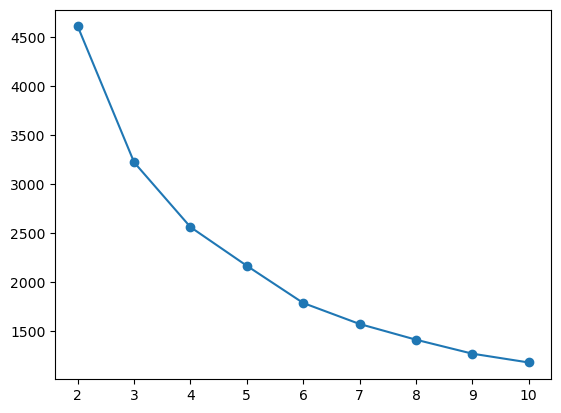

In [547]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans

# Use elbow method
wcss = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)


plt.plot(range(2,11), wcss, marker='o')
plt.show()

c:\Users\Hugo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


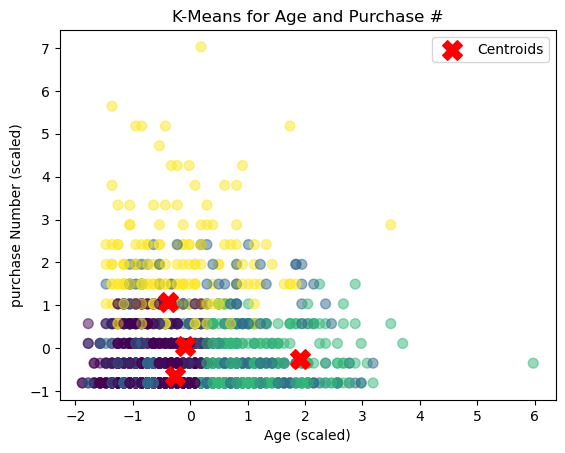

In [548]:
# Train algorithm
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans.fit(df_scaled)
# define labels
cluster_labels = kmeans.labels_

# columns = [NUMERO_COMPRAS, EDAD, TOTAL_COMPRADO, GENERO_Femenino, GENERO_Masculino]
plt.scatter(df_scaled[:,1], df_scaled[:,0], c=cluster_labels, cmap='viridis', s=50, alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means for Age and Purchase #')
plt.legend()
plt.xlabel('Age (scaled)')
plt.ylabel('purchase Number (scaled)')
plt.show()

c:\Users\Hugo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


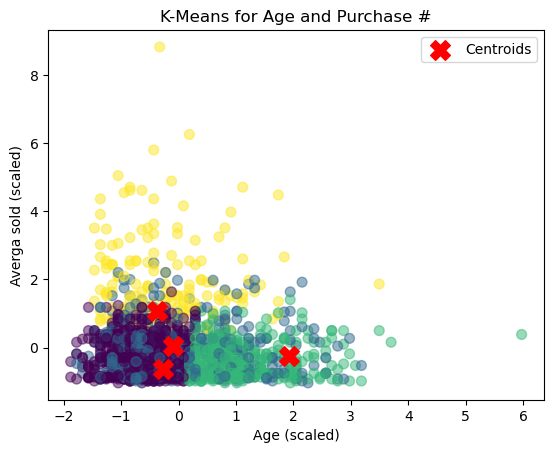

In [567]:
# Train algorithm
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans.fit(df_scaled)
# define labels
cluster_labels = kmeans.labels_

# columns = [NUMERO_COMPRAS, EDAD, TOTAL_COMPRADO, GENERO_Femenino, GENERO_Masculino]
plt.scatter(df_scaled[:,1], df_scaled[:,2], c=cluster_labels, cmap='viridis', s=50, alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means for Age and Purchase #')
plt.legend()
plt.xlabel('Age (scaled)')
plt.ylabel('Averga sold (scaled)')
plt.show()

In [549]:
df_km['CLUSTERS'] = kmeans.labels_
#df_km

In [550]:
df_km['CLUSTERS'].value_counts()

CLUSTERS
0    587
1    410
2    364
3    176
Name: count, dtype: int64

In [551]:
df_km.groupby(['CLUSTERS', 'GENERO']).agg(
    edad = ('EDAD', 'mean'),
    compras = ('NUMERO_COMPRAS', 'mean'),
    genero = ('GENERO', 'count'),
    total = ('TOTAL_COMPRADO', 'mean')
).reset_index()

C:\Users\Hugo\AppData\Local\Temp\ipykernel_11304\2304490244.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_km.groupby(['CLUSTERS', 'GENERO']).agg(


,CLUSTERS,GENERO,edad,compras,genero,total
0,0,Femenino,30.029545,2.156818,440,83472.152273
1,0,Masculino,29.850340,2.170068,147,79925.163265
2,1,Femenino,36.228873,2.591549,284,98735.915493
3,1,Masculino,37.920635,2.436508,126,97686.650794
4,2,Femenino,46.274436,1.902256,266,67392.285714
5,2,Masculino,47.642857,1.979592,98,81255.102041
6,3,Femenino,34.577236,6.869919,123,269425.983577
7,3,Masculino,32.075472,7.037736,53,288094.226415


##### Analysis on Cluster 3

In this analysis we can found tht the cluster 3 has greatest average on purchase number

In [559]:
cltr_3 = df_km.loc[df_km['CLUSTERS'] == 3]['NUMERO_DE_IDENTIFICACION'].tolist()

In [560]:
# Leaving 2024 customers only, due each course expires each two years
df_fv = df_fv.loc[df_fv['ANIO_VENTA'] == 2024]

# Leaving next month curstomers
df_fv = df_fv.loc[df_fv['MES_VENTA'] == 'Julio']

In [561]:

df_fv2 = df_fv.loc[df_fv['NUMERO_DE_IDENTIFICACION'].isin(cltr_3)]
df_fv2['PROFESION'] = df_fv2['PROFESION'].cat.remove_unused_categories()
df_fv2.drop_duplicates(subset=['NUMERO_DE_IDENTIFICACION'], keep='last', inplace=True)
df_fv2['PROFESION'].value_counts()

C:\Users\Hugo\AppData\Local\Temp\ipykernel_11304\1163922972.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fv2['PROFESION'] = df_fv2['PROFESION'].cat.remove_unused_categories()
C:\Users\Hugo\AppData\Local\Temp\ipykernel_11304\1163922972.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fv2.drop_duplicates(subset=['NUMERO_DE_IDENTIFICACION'], keep='last', inplace=True)


PROFESION
Auxiliar de enfermería                   3
Tecnólogo en atención prehospitalaria    3
Médico general                           2
Fisioterapeuta                           1
Name: count, dtype: int64

In [562]:
df_fv2.columns.tolist()

['NUMERO_DE_IDENTIFICACION',
 'PRIMER_APELLIDO',
 'SEGUNDO_APELLIDO',
 'PRIMER_NOMBRE',
 'SEGUNDO_NOMBRE',
 'CURSO',
 'CELULAR',
 'CORREO',
 'PRECIO_NETO',
 'FECHA_DE_PAGO',
 'RENOVACION',
 'FECHA_DE_VENTA',
 'PROFESION',
 'GENERO',
 'FECHA_DE_NACIMIENTO',
 'CIUDAD_REGION',
 'MODALIDAD',
 'PROCEDENCIA',
 'MEDIO_DE_PAGO',
 'RESPONSABLE_VENTA',
 'ELABORO',
 'EDAD',
 'ANIO_VENTA',
 'MES_VENTA',
 'GRUPO_EDAD']

In [563]:
df_fv2.dropna(inplace=True)
resumen_cltr_3 = df_fv2.groupby(['GENERO', 'GRUPO_EDAD']).agg(
    estudiantes = ('NUMERO_DE_IDENTIFICACION', 'count')
).reset_index()
resumen_cltr_3

C:\Users\Hugo\AppData\Local\Temp\ipykernel_11304\1788506239.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fv2.dropna(inplace=True)
C:\Users\Hugo\AppData\Local\Temp\ipykernel_11304\1788506239.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_cltr_3 = df_fv2.groupby(['GENERO', 'GRUPO_EDAD']).agg(


,GENERO,GRUPO_EDAD,estudiantes
0,Femenino,Menor,0
1,Femenino,Joven,2
2,Femenino,Adulto,2
3,Femenino,Senior,0
4,Masculino,Menor,0
5,Masculino,Joven,3
6,Masculino,Adulto,2
7,Masculino,Senior,0
8,UNKNOWN,Menor,0
9,UNKNOWN,Joven,0


In [565]:
# Customers from cluster 3 which has greatest average of purchases and in average 33 years old

#df_fv2[['NUMERO_DE_IDENTIFICACION','PRIMER_APELLIDO', 'PRIMER_NOMBRE', 'CELULAR', 'CORREO']]